### Data and Methodology

#### Google Maps Static API Key Setup

Before running this notebook, ensure you have a Google Maps API Key. If you don't already have one, follow these steps:

1.  **Create a Project and Enable API:** Go to the [Google Cloud Console](https://console.cloud.google.com/) and create a new project. Enable the "Maps Static API" for your project.
2.  **Create API Key:** Upon enabling Maps Static API, a "Maps Platform API Key" will be automatically created. Otherwise, navigate to "APIs & Services" > "Credentials" and create an API key using default settings.
3.  **Add to Colab Secrets:** In Google Colab, click on the "🔑 Secrets" tab (usually on the left sidebar). Add a new secret with the name `GOOGLE_MAPS_API_KEY` and paste your API key as its value. Ensure "Notebook access" is enabled for this secret.

#### Packages installation

In [ ]:
!pip install -q geopandas osmnx pyproj shapely fiona pyogrio

import geopandas as gpd
import pandas as pd
import fiona
import matplotlib.pyplot as plt
from pathlib import Path
import os
import requests
import shutil
import numpy as np
import math
import time
import random
import json
from time import sleep
import osmnx as ox
from shapely.geometry import Point
from shapely.ops import unary_union
from PIL import Image
from google.colab import userdata

GOOGLE_MAPS_API_KEY = userdata.get("GOOGLE_MAPS_API_KEY")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.0 MB/s eta 0:00:00


#### Data validation

TO BE EDIT

In [ ]:
# Load data
fiona.drvsupport.supported_drivers["KML"] = "rw"
files = [
    "/content/all_warehouses_cleaned_0.kml",
    "/content/all_warehouses_cleaned_2000.kml",
    "/content/all_warehouses_cleaned_4000.kml",
    "/content/all_warehouses_fixed.kml"
]
clean_files = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        content = f.read()
    start = content.find("<?xml")
    cleaned_content = content[start:]
    clean_name = file.replace(".kml", "_clean.kml")
    with open(clean_name, "w", encoding="utf-8") as f:
        f.write(cleaned_content)
    clean_files.append(clean_name)

gdfs = []
for file in clean_files:
    gdf = gpd.read_file(file, driver="KML")
    gdfs.append(gdf)
print("All files loaded.")

All files loaded.


In [ ]:
# EDA
merged_gdf = pd.concat(gdfs, ignore_index=True)
print("Total merged points:", len(merged_gdf))

Total merged points: 4702


In [ ]:
merged_gdf["longitude"] = merged_gdf.geometry.x
merged_gdf["latitude"] = merged_gdf.geometry.y

# Find duplicated pairs
duplicates = merged_gdf[merged_gdf.duplicated(subset=["latitude","longitude"], keep=False)]
print("Duplicate rows:", len(duplicates))
show = duplicates[["latitude", "longitude"]].sort_values(by=["latitude", "longitude"])
show.head(6)

Duplicate rows: 942


,latitude,longitude
4181,-37.847625,144.785354
4532,-37.847625,144.785354
4254,4.634895,-74.123196
4605,4.634895,-74.123196
4098,7.084981,-73.137407
4449,7.084981,-73.137407


In [ ]:
# Drop duplicates
gdf_unique = merged_gdf.drop_duplicates(subset=["latitude","longitude"])
print("Duplicate rows:", len(duplicates))
print("Before:", len(merged_gdf))
print("After:", len(gdf_unique))

Duplicate rows: 942
Before: 4702
After: 4205


#### Data Visualization

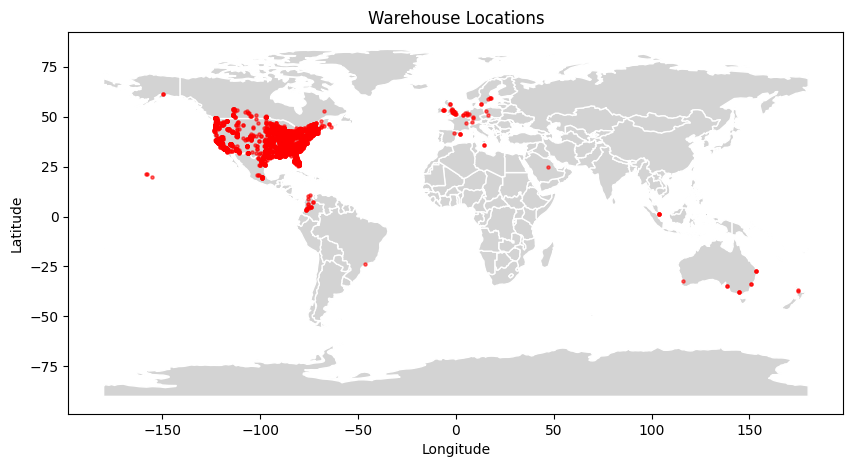

In [ ]:
# Load world map directly from Natural Earth
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
fig, ax = plt.subplots(figsize=(10,6))

# Plot warehouse locations
world.plot(ax=ax, color="lightgray", edgecolor="white")
merged_gdf.plot(ax=ax, markersize=5, color="red", alpha=0.6)
plt.title("Warehouse Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

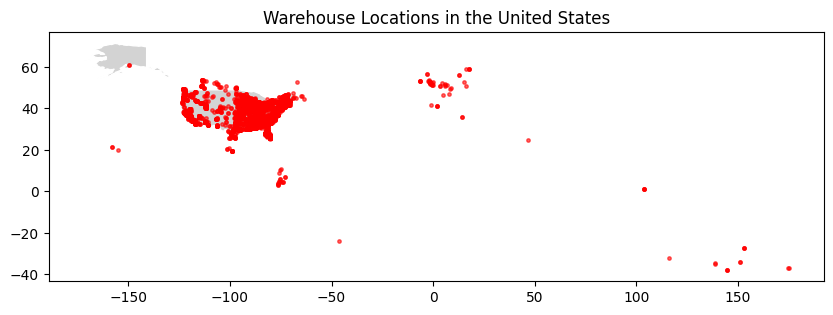

In [ ]:
# Plot warehouse locations in the U.S.
us = world[world["ADMIN"] == "United States of America"]
fig, ax = plt.subplots(figsize=(10,6))
us.plot(ax=ax, color="lightgray", edgecolor="white")
merged_gdf.plot(ax=ax, markersize=6, color="red", alpha=0.6)
plt.title("Warehouse Locations in the United States")
plt.show()

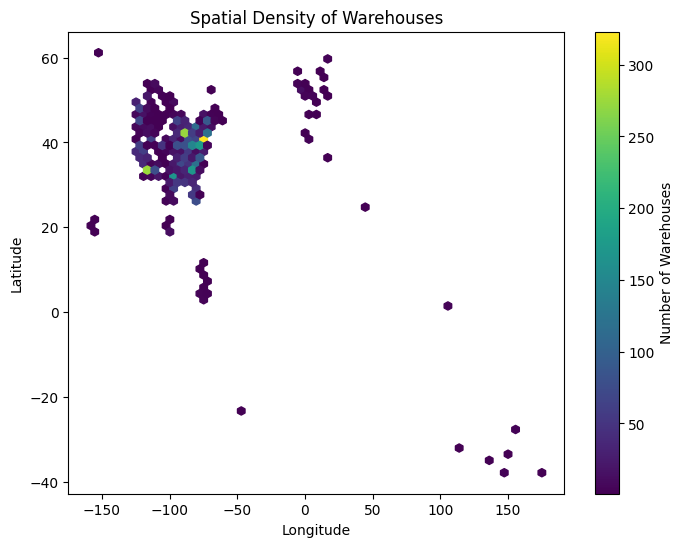

In [ ]:
# Plot spatial density of warehouse
plt.figure(figsize=(8,6))
plt.hexbin(merged_gdf["longitude"], merged_gdf["latitude"], gridsize=60, mincnt=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Density of Warehouses")
plt.colorbar(label="Number of Warehouses")
plt.show()

#### Negative sampling approaches

##### Method 1

In [ ]:
# Load data
file_path = "/content/all_warehouses_cleaned_4000.kml"
fixed_path = "/content/all_warehouses_fixed.kml"
with open(file_path, 'r', encoding='utf-8') as f:
    content = f.read()
# Strip leading whitespace/newlines and write to a new file
with open(fixed_path, 'w', encoding='utf-8') as f:
    f.write(content.lstrip())
print("File cleaned! Now try loading 'all_warehouses_fixed.kml'.")

File cleaned! Now try loading 'all_warehouses_fixed.kml'.


In [ ]:
cwd = Path.cwd()
print("Current working dir:", cwd)

kml_name = "all_warehouses_fixed.kml"
kml_path = cwd / kml_name
print("KML exists?", kml_path.exists(), kml_path)
if not kml_path.exists():
    raise FileNotFoundError(kml_path)
print("Fiona KML drivers:", [k for k in fiona.supported_drivers if "KML" in k.upper()])

try:
    gdf = gpd.read_file(kml_path, engine="pyogrio")
    print("Loaded with pyogrio")
except Exception as pyogrio_err:
    print("pyogrio failed:", repr(pyogrio_err))
    fiona_has_kml = any("KML" in k.upper() for k in fiona.supported_drivers)
    if not fiona_has_kml:
        raise RuntimeError(
            "KML read failed: pyogrio failed and Fiona has no KML/LIBKML driver. "
            "Use conda-forge GDAL/Fiona build or convert KML to GeoJSON."
        ) from pyogrio_err
    gdf = gpd.read_file(kml_path, engine="fiona")
    print("Loaded with fiona")

print(gdf.head())
print("Rows:", len(gdf), "CRS:", gdf.crs)

Current working dir: /content
KML exists? True /content/all_warehouses_fixed.kml
Fiona KML drivers: ['KML']
Loaded with pyogrio
     id                                  Name  \
0  None  64ca7587-a0b0-49d4-b140-74d691d72465   
1  None  5def5206-f194-471a-ad37-6799230ace36   
2  None  0210fd59-e763-43de-ac46-9588cbc9a57b   
3  None  3c45b517-3152-47bd-a79a-0eec76bd6714   
4  None  4f273068-b659-4901-addf-c1f6b15d7b36   

                                         description timestamp begin end  \
0  \n        <b>ID: 64ca7587-a0b0-49d4-b140-74d69...       NaT   NaT NaT   
1  \n        <b>ID: 5def5206-f194-471a-ad37-67992...       NaT   NaT NaT   
2  \n        <b>ID: 0210fd59-e763-43de-ac46-9588c...       NaT   NaT NaT   
3  \n        <b>ID: 3c45b517-3152-47bd-a79a-0eec7...       NaT   NaT NaT   
4  \n        <b>ID: 4f273068-b659-4901-addf-c1f6b...       NaT   NaT NaT   

  altitudeMode  tessellate  extrude  visibility  drawOrder  icon  \
0         None          -1        0          -1     

In [ ]:
# NOTE: The following code is exploratory and non-functional in this pipeline.
# It references Google Earth Engine (ee) and satellite_collection which are not defined.
# Kept for reference only — do not run.

# def export_chip(feature):
#     geom = feature.geometry().buffer(100).bounds()
#     task = ee.batch.Export.image.toDrive(
#         image=satellite_collection.median(),
#         description=f"warehouse_{feature.id()}",
#         region=geom,
#         scale=1
#     )
#     task.start()

gdf = gpd.read_file(kml_path, engine="pyogrio")
print([k for k in fiona.supported_drivers.keys() if "KML" in k.upper()])

['KML']


In [ ]:
url = f"https://maps.googleapis.com/maps/api/staticmap?center=40.7128,-74.0060&zoom=18&size=512x512&maptype=satellite&key={GOOGLE_MAPS_API_KEY}"
r = requests.get(url, timeout=20)
print(r.status_code, r.headers.get("content-type"), len(r.content))
print(r.text[:200] if "text" in (r.headers.get("content-type") or "") else "binary image")

200 image/png 203449
binary image


In [ ]:
os.makedirs("warehouse_dataset", exist_ok=True)

def download_tiles(gdf, api_key):
    for idx, row in gdf.iterrows():
        lat = row.geometry.y
        lon = row.geometry.x
        url = f"https://maps.googleapis.com/maps/api/staticmap?center={lat},{lon}&zoom=18&size=512x512&maptype=satellite&key={api_key}"
        r = requests.get(url, timeout=20)
        if r.status_code == 200:
            with open(f"warehouse_dataset/img_{idx}.jpg", "wb") as f:
                f.write(r.content)
        if idx % 50 == 0:
            print(f"Progress: {idx}/{len(gdf)}")

download_tiles(gdf, GOOGLE_MAPS_API_KEY)

Progress: 0/351
Progress: 50/351
Progress: 100/351
Progress: 150/351
Progress: 200/351
Progress: 250/351
Progress: 300/351
Progress: 350/351


In [ ]:
files = os.listdir('warehouse_dataset')
print(f"Total files found: {len(files)}")
if len(files) > 0:
    print("First 5 files:", files[:5])

Total files found: 351
First 5 files: ['img_264.jpg', 'img_20.jpg', 'img_348.jpg', 'img_137.jpg', 'img_120.jpg']


In [ ]:
# format: make_archive('output_name', 'format', 'source_folder')
shutil.make_archive('warehouse_images', 'zip', 'warehouse_dataset')

'/content/warehouse_images.zip'

In [ ]:
os.makedirs('negative_samples', exist_ok=True)

def download_negatives(gdf, api_key, offset_meters=800):
    # Degree approximation: 1 degree is roughly 111,000 meters
    deg_offset = offset_meters / 111000.0
    for idx, row in gdf.iterrows():
        # Randomly choose a direction to shift (North, South, East, or West)
        angle = np.random.uniform(0, 2 * np.pi)
        lat_offset = row.geometry.y + (deg_offset * np.sin(angle))
        lon_offset = row.geometry.x + (deg_offset * np.cos(angle))
        url = f"https://maps.googleapis.com/maps/api/staticmap?center={lat_offset},{lon_offset}&zoom=18&size=512x512&maptype=satellite&key={api_key}"
        response = requests.get(url)
        if response.status_code == 200:
            with open(f"negative_samples/neg_{idx}.jpg", "wb") as f:
                f.write(response.content)
        if idx % 50 == 0:
            print(f"Downloaded {idx} negative samples...")

download_negatives(gdf, GOOGLE_MAPS_API_KEY)

Downloaded 0 negative samples...
Downloaded 50 negative samples...
Downloaded 100 negative samples...
Downloaded 150 negative samples...
Downloaded 200 negative samples...
Downloaded 250 negative samples...
Downloaded 300 negative samples...
Downloaded 350 negative samples...


In [ ]:
# ====== Experiment scale ======
TARGET_SAMPLE_SIZE = 1000

# Distance parameters for negative sample generation
MIN_OFFSET_M = 1500
MAX_OFFSET_M = 5000

# Places screening radius
PLACES_RADIUS_M = 300

# Semantic naming (no more v1/v2)
NEG_STRATEGY = f"random_offset_{MIN_OFFSET_M}_{MAX_OFFSET_M}m"
NEG_DIR = f"negative_samples_{NEG_STRATEGY}_{TARGET_SAMPLE_SIZE}"
META_DIR = f"metadata_{NEG_STRATEGY}_{TARGET_SAMPLE_SIZE}"
Path(NEG_DIR).mkdir(exist_ok=True)
Path(META_DIR).mkdir(exist_ok=True)

# Keywords for Stage 1 map screening
STRONG_WAREHOUSE_TERMS = [
    "warehouse", "distribution center", "fulfillment center",
    "logistics", "depot", "storage", "freight", "crossdock", "cross dock"
]
SOFT_RISK_TERMS = [
    "industrial", "business park", "supply", "truck", "shipping", "terminal"
]

# API keys loaded from Colab Secrets in cell 2
GOOGLE_KEY = GOOGLE_MAPS_API_KEY
print("Google key ready")

# Check gdf
print("gdf exists:", "gdf" in globals())
if "gdf" in globals():
    print("gdf rows:", len(gdf))
    print("target sample size:", TARGET_SAMPLE_SIZE)
    if TARGET_SAMPLE_SIZE > len(gdf):
        print("Sampling with replacement will be used to reach the target sample size.")

Google key ready
gdf exists: True
gdf rows: 351
target sample size: 1000
Sampling with replacement will be used to reach the target sample size.


In [ ]:
def random_offset_latlon(lat, lon, min_m=1500, max_m=5000):
    d = random.uniform(min_m, max_m)
    theta = random.uniform(0, 2 * math.pi)

    dlat = (d / 111000.0) * math.sin(theta)
    # Apply latitude-aware correction for longitude conversion
    dlon = (d / (111000.0 * max(math.cos(math.radians(lat)), 1e-6))) * math.cos(theta)

    return lat + dlat, lon + dlon, d


def download_static_satellite(lat, lon, api_key, zoom=18, size="512x512"):
    url = (
        "https://maps.googleapis.com/maps/api/staticmap"
        f"?center={lat},{lon}&zoom={zoom}&size={size}&maptype=satellite&key={api_key}"
    )
    r = requests.get(url, timeout=20)
    return r


assert "gdf" in globals(), "gdf is missing. Run the KML loading cell first."
assert TARGET_SAMPLE_SIZE > 0, "TARGET_SAMPLE_SIZE must be greater than 0"

neg_records = []
source_n = len(gdf)
sample_n = TARGET_SAMPLE_SIZE

# Sampling with replacement allows reaching 1000 even when gdf has 351 rows
sampled_indices = np.random.choice(source_n, size=sample_n, replace=True)

for i, src_idx in enumerate(sampled_indices):
    row = gdf.iloc[int(src_idx)]
    base_lat = float(row.geometry.y)
    base_lon = float(row.geometry.x)

    neg_lat, neg_lon, offset_m = random_offset_latlon(base_lat, base_lon, MIN_OFFSET_M, MAX_OFFSET_M)
    resp = download_static_satellite(neg_lat, neg_lon, GOOGLE_KEY)

    img_path = f"{NEG_DIR}/neg_{i}.jpg"
    ok = (resp.status_code == 200 and "image" in resp.headers.get("content-type", ""))

    if ok:
        with open(img_path, "wb") as f:
            f.write(resp.content)

    neg_records.append({
        "neg_id": i,
        "src_idx": int(src_idx),
        "src_lat": base_lat,
        "src_lon": base_lon,
        "neg_lat": neg_lat,
        "neg_lon": neg_lon,
        "offset_m": offset_m,
        "img_path": img_path,
        "img_download_ok": ok,
        "img_status_code": resp.status_code,
        "img_content_type": resp.headers.get("content-type", "")
    })

    if i % 100 == 0:
        print(f"Generated {i}/{sample_n}")

neg_df = pd.DataFrame(neg_records)
neg_meta_path = f"{META_DIR}/neg_candidates_{NEG_STRATEGY}_{sample_n}.csv"
neg_df.to_csv(neg_meta_path, index=False)

print("Done.")
print("Source gdf rows:", source_n)
print("Target candidates:", sample_n)
print("Actual generated:", len(neg_df))
print("Image downloaded:", int(neg_df["img_download_ok"].sum()))
print("Negative image folder:", NEG_DIR)
print("Metadata csv:", neg_meta_path)
print(neg_df.head(3))

Generated 0/1000
Generated 100/1000
Generated 200/1000
Generated 300/1000
Generated 400/1000
Generated 500/1000
Generated 600/1000
Generated 700/1000
Generated 800/1000
Generated 900/1000
Done.
Source gdf rows: 351
Target candidates: 1000
Actual generated: 1000
Image downloaded: 1000
Negative image folder: negative_samples_random_offset_1500_5000m_1000
Metadata csv: metadata_random_offset_1500_5000m_1000/neg_candidates_random_offset_1500_5000m_1000.csv
   neg_id  src_idx    src_lat     src_lon    neg_lat     neg_lon     offset_m  \
0       0      112  40.531914 -111.890795  40.507082 -111.863430  3595.496816   
1       1      103  36.093586  -88.998502  36.125730  -88.967027  4549.792569   
2       2      296  43.619388  -79.773567  43.606038  -79.779558  1558.060830   

                                            img_path  img_download_ok  \
0  negative_samples_random_offset_1500_5000m_1000...             True   
1  negative_samples_random_offset_1500_5000m_1000...             True   

In [ ]:
# Cell 3: Map API category screening (Stage 1, safety-controlled dry run)
# Runs only 100 samples by default. Switch to full run after validation.


assert "neg_df" in globals(), "neg_df is missing. Run the previous negative-sample cell first."
assert "GOOGLE_KEY" in globals() and GOOGLE_KEY, "GOOGLE_KEY is missing. Run the config cell first."

# ===== Safety switches (small-sample first) =====
DRY_RUN = True               # True: run safety test on small sample
DRY_RUN_SIZE = 100           # dry-run sample size
FULL_RUN_SIZE = 1000         # full-run upper bound
ALLOW_FULL_RUN = False       # keep False until dry run is validated

# Places API parameters
PLACES_RADIUS_M = 300
PLACES_LIMIT_TOPK = 10

# Strong-risk keywords: direct remove when matched
STRONG_WAREHOUSE_TERMS = [
    "warehouse", "distribution center", "fulfillment center", "fulfilment center",
    "logistics", "depot", "storage", "freight", "crossdock", "cross dock"
]

# Soft-risk keywords: move to review bucket (next-stage LLM)
SOFT_RISK_TERMS = [
    "industrial", "business park", "supply", "truck", "shipping", "terminal"
]


def nearby_places(lat, lon, api_key, radius=300):
    url = (
        "https://maps.googleapis.com/maps/api/place/nearbysearch/json"
        f"?location={lat},{lon}&radius={radius}&key={api_key}"
    )
    r = requests.get(url, timeout=25)
    if r.status_code != 200:
        return {
            "http_status": r.status_code,
            "places_status": "HTTP_ERROR",
            "results": []
        }
    data = r.json()
    return {
        "http_status": 200,
        "places_status": data.get("status", "UNKNOWN"),
        "results": data.get("results", [])
    }


def keyword_hits(text_blob, keywords):
    t = (text_blob or "").lower()
    return [kw for kw in keywords if kw in t]


# ===== Select run subset =====
if DRY_RUN:
    run_size = min(DRY_RUN_SIZE, len(neg_df))
    stage1_input_df = neg_df.head(run_size).copy()
    run_tag = f"dryrun_{run_size}"
else:
    run_size = min(FULL_RUN_SIZE, len(neg_df))
    if run_size > DRY_RUN_SIZE and not ALLOW_FULL_RUN:
        raise ValueError(
            f"Full mode selected with {run_size} planned Places API calls. "
            "Set ALLOW_FULL_RUN=True before running."
        )
    stage1_input_df = neg_df.head(run_size).copy()
    run_tag = f"fullrun_{run_size}"

print(f"[Stage1] Run tag: {run_tag}")
print(f"[Stage1] Planned Places API calls: {len(stage1_input_df)}")
print("[Stage1] Validate dry-run outputs first, then enable full run.")

stage1_records = []

for i, row in stage1_input_df.iterrows():
    lat, lon = float(row["neg_lat"]), float(row["neg_lon"])

    resp = nearby_places(lat, lon, GOOGLE_KEY, radius=PLACES_RADIUS_M)
    places = resp["results"][:PLACES_LIMIT_TOPK]

    poi_items = []
    blob = ""
    for p in places:
        name = p.get("name", "")
        types = p.get("types", [])
        types_text = ",".join(types)
        one = f"{name} | {types_text}"
        poi_items.append(one)
        blob += " " + one.lower()

    strong_hits = keyword_hits(blob, STRONG_WAREHOUSE_TERMS)
    soft_hits = keyword_hits(blob, SOFT_RISK_TERMS)

    if len(strong_hits) > 0:
        stage1_decision = "remove_by_map_strong"
    elif len(soft_hits) > 0:
        stage1_decision = "review_by_map_soft"
    else:
        stage1_decision = "keep_after_map"

    stage1_records.append({
        **row.to_dict(),
        "places_http_status": resp["http_status"],
        "places_status": resp["places_status"],
        "places_count_topk": len(places),
        "poi_topk": json.dumps(poi_items, ensure_ascii=False),
        "map_strong_hits": json.dumps(strong_hits, ensure_ascii=False),
        "map_soft_hits": json.dumps(soft_hits, ensure_ascii=False),
        "stage1_decision": stage1_decision,
        "run_tag": run_tag
    })

    if len(stage1_records) % 50 == 0:
        print(f"Stage1 progress: {len(stage1_records)}/{len(stage1_input_df)}")
    time.sleep(0.03)


stage1_df = pd.DataFrame(stage1_records)

# Save full table and split outputs
stage1_all_path = f"{META_DIR}/stage1_map_screened_{NEG_STRATEGY}_{run_tag}.csv"
stage1_removed_path = f"{META_DIR}/stage1_removed_by_map_{NEG_STRATEGY}_{run_tag}.csv"
stage1_review_path = f"{META_DIR}/stage1_review_by_map_{NEG_STRATEGY}_{run_tag}.csv"
stage1_keep_path = f"{META_DIR}/stage1_keep_after_map_{NEG_STRATEGY}_{run_tag}.csv"

stage1_df.to_csv(stage1_all_path, index=False)
stage1_df[stage1_df["stage1_decision"] == "remove_by_map_strong"].to_csv(stage1_removed_path, index=False)
stage1_df[stage1_df["stage1_decision"] == "review_by_map_soft"].to_csv(stage1_review_path, index=False)
stage1_df[stage1_df["stage1_decision"] == "keep_after_map"].to_csv(stage1_keep_path, index=False)

# Summary statistics
c_removed = int((stage1_df["stage1_decision"] == "remove_by_map_strong").sum())
c_review = int((stage1_df["stage1_decision"] == "review_by_map_soft").sum())
c_keep = int((stage1_df["stage1_decision"] == "keep_after_map").sum())

print("\n=== Stage 1 (Map screening) Summary ===")
print("Run tag:", run_tag)
print("Total:", len(stage1_df))
print("remove_by_map_strong:", c_removed)
print("review_by_map_soft:", c_review)
print("keep_after_map:", c_keep)
print("\nSaved:")
print(stage1_all_path)
print(stage1_removed_path)
print(stage1_review_path)
print(stage1_keep_path)

cols_show = ["neg_id", "neg_lat", "neg_lon", "places_status", "map_strong_hits", "map_soft_hits", "poi_topk"]
print("\nRemoved sample examples (top 10):")
display(stage1_df[stage1_df["stage1_decision"] == "remove_by_map_strong"][cols_show].head(10))

print("\nReview sample examples (top 10):")
display(stage1_df[stage1_df["stage1_decision"] == "review_by_map_soft"][cols_show].head(10))

[Stage1] Run tag: dryrun_100
[Stage1] Planned Places API calls: 100
[Stage1] Validate dry-run outputs first, then enable full run.
Stage1 progress: 50/100
Stage1 progress: 100/100

=== Stage 1 (Map screening) Summary ===
Run tag: dryrun_100
Total: 100
remove_by_map_strong: 0
review_by_map_soft: 0
keep_after_map: 100

Saved:
metadata_random_offset_1500_5000m_1000/stage1_map_screened_random_offset_1500_5000m_dryrun_100.csv
metadata_random_offset_1500_5000m_1000/stage1_removed_by_map_random_offset_1500_5000m_dryrun_100.csv
metadata_random_offset_1500_5000m_1000/stage1_review_by_map_random_offset_1500_5000m_dryrun_100.csv
metadata_random_offset_1500_5000m_1000/stage1_keep_after_map_random_offset_1500_5000m_dryrun_100.csv

Removed sample examples (top 10):


,neg_id,neg_lat,neg_lon,places_status,map_strong_hits,map_soft_hits,poi_topk



Review sample examples (top 10):


,neg_id,neg_lat,neg_lon,places_status,map_strong_hits,map_soft_hits,poi_topk


In [ ]:
# Cell 4: Create manual review folders (copy images by Stage1 result)
# This copies files only and does not move original images.


assert "META_DIR" in globals(), "META_DIR is missing. Run the config cell first."

# Default to the latest dry-run output
RUN_TAG = "dryrun_100"
stage1_csv = Path(META_DIR) / f"stage1_map_screened_{NEG_STRATEGY}_{RUN_TAG}.csv"

if not stage1_csv.exists():
    raise FileNotFoundError(f"Stage1 output file not found: {stage1_csv}")

stage1_df = pd.read_csv(stage1_csv)

manual_root = Path(META_DIR) / f"manual_review_{NEG_STRATEGY}_{RUN_TAG}"
removed_dir = manual_root / "removed_by_map"
review_dir = manual_root / "review_by_map"
keep_dir = manual_root / "keep_after_map"

for d in [removed_dir, review_dir, keep_dir]:
    d.mkdir(parents=True, exist_ok=True)


def copy_group(df, target_dir):
    copied = 0
    missed = 0
    for _, r in df.iterrows():
        src = Path(str(r["img_path"]))
        if src.exists():
            # Prefix with neg_id to avoid accidental filename collisions
            dst = target_dir / f"neg_{int(r['neg_id'])}_{src.name}"
            shutil.copy2(src, dst)
            copied += 1
        else:
            missed += 1
    return copied, missed

removed_df = stage1_df[stage1_df["stage1_decision"] == "remove_by_map_strong"].copy()
review_df = stage1_df[stage1_df["stage1_decision"] == "review_by_map_soft"].copy()
keep_df = stage1_df[stage1_df["stage1_decision"] == "keep_after_map"].copy()

removed_copied, removed_missed = copy_group(removed_df, removed_dir)
review_copied, review_missed = copy_group(review_df, review_dir)
keep_copied, keep_missed = copy_group(keep_df, keep_dir)

summary = {
    "stage1_csv": str(stage1_csv),
    "manual_root": str(manual_root),
    "removed_count": int(len(removed_df)),
    "review_count": int(len(review_df)),
    "keep_count": int(len(keep_df)),
    "removed_copied": int(removed_copied),
    "review_copied": int(review_copied),
    "keep_copied": int(keep_copied),
    "removed_missed": int(removed_missed),
    "review_missed": int(review_missed),
    "keep_missed": int(keep_missed),
}

print("Manual review folder ready:")
for k, v in summary.items():
    print(f"- {k}: {v}")

# Optional: export manifests for cross-checking
removed_df.to_csv(manual_root / "removed_manifest.csv", index=False)
review_df.to_csv(manual_root / "review_manifest.csv", index=False)
keep_df.to_csv(manual_root / "keep_manifest.csv", index=False)
print("\nManifest files saved in manual_root.")

Manual review folder ready:
- stage1_csv: metadata_random_offset_1500_5000m_1000/stage1_map_screened_random_offset_1500_5000m_dryrun_100.csv
- manual_root: metadata_random_offset_1500_5000m_1000/manual_review_random_offset_1500_5000m_dryrun_100
- removed_count: 0
- review_count: 0
- keep_count: 100
- removed_copied: 0
- review_copied: 0
- keep_copied: 100
- removed_missed: 0
- review_missed: 0
- keep_missed: 0

Manifest files saved in manual_root.


In [ ]:
# Cell 5: Map screening (single-standard version, lower false removal risk)
# Different from the previous version: no direct remove, only high_risk / review / keep.


assert "neg_df" in globals(), "neg_df is missing. Run the negative sample generation cell first."
assert "GOOGLE_KEY" in globals() and GOOGLE_KEY, "GOOGLE_KEY is missing. Run the config cell first."
assert "META_DIR" in globals(), "META_DIR is missing. Run the config cell first."

# Safety-test parameters
DRY_RUN = True
DRY_RUN_SIZE = 100
FULL_RUN_SIZE = 1000
ALLOW_FULL_RUN = False

PLACES_RADIUS_M = 300
PLACES_LIMIT_TOPK = 10

# Single-standard core terms (no direct delete, only high-risk label)
CORE_WAREHOUSE_TERMS = [
    "warehouse", "distribution center", "fulfillment center", "fulfilment center"
]

RELATED_TERMS = [
    "logistics", "depot", "freight", "crossdock", "cross dock", "storage"
]

SOFT_CONTEXT_TERMS = [
    "industrial", "business park", "truck", "shipping", "terminal", "supply"
]


def nearby_places(lat, lon, api_key, radius=300):
    url = (
        "https://maps.googleapis.com/maps/api/place/nearbysearch/json"
        f"?location={lat},{lon}&radius={radius}&key={api_key}"
    )
    r = requests.get(url, timeout=25)
    if r.status_code != 200:
        return {"http_status": r.status_code, "places_status": "HTTP_ERROR", "results": []}
    data = r.json()
    return {
        "http_status": 200,
        "places_status": data.get("status", "UNKNOWN"),
        "results": data.get("results", [])
    }


def hits(text_blob, keywords):
    t = (text_blob or "").lower()
    return [kw for kw in keywords if kw in t]


if DRY_RUN:
    run_size = min(DRY_RUN_SIZE, len(neg_df))
    stage1_input_df = neg_df.head(run_size).copy()
    run_tag = f"dryrun_{run_size}_single_standard"
else:
    run_size = min(FULL_RUN_SIZE, len(neg_df))
    if run_size > DRY_RUN_SIZE and not ALLOW_FULL_RUN:
        raise ValueError(f"Planned {run_size} Places API calls. Set ALLOW_FULL_RUN=True first.")
    stage1_input_df = neg_df.head(run_size).copy()
    run_tag = f"fullrun_{run_size}_single_standard"

print(f"[Stage1-SS] Run tag: {run_tag}")
print(f"[Stage1-SS] Planned Places API calls: {len(stage1_input_df)}")

records = []
for n, (_, row) in enumerate(stage1_input_df.iterrows(), start=1):
    lat, lon = float(row["neg_lat"]), float(row["neg_lon"])
    resp = nearby_places(lat, lon, GOOGLE_KEY, radius=PLACES_RADIUS_M)
    places = resp["results"][:PLACES_LIMIT_TOPK]

    poi_items, blob = [], ""
    for p in places:
        name = p.get("name", "")
        types = ",".join(p.get("types", []))
        one = f"{name} | {types}"
        poi_items.append(one)
        blob += " " + one.lower()

    core_hits = hits(blob, CORE_WAREHOUSE_TERMS)
    rel_hits = hits(blob, RELATED_TERMS)
    soft_hits = hits(blob, SOFT_CONTEXT_TERMS)

    # Single-standard approach: no direct deletion, only risk-level routing
    if len(core_hits) > 0:
        decision = "high_risk_by_map"
    elif len(rel_hits) > 0 or len(soft_hits) > 0:
        decision = "review_by_map"
    else:
        decision = "keep_after_map"

    records.append({
        **row.to_dict(),
        "places_http_status": resp["http_status"],
        "places_status": resp["places_status"],
        "places_count_topk": len(places),
        "poi_topk": json.dumps(poi_items, ensure_ascii=False),
        "core_hits": json.dumps(core_hits, ensure_ascii=False),
        "related_hits": json.dumps(rel_hits, ensure_ascii=False),
        "soft_hits": json.dumps(soft_hits, ensure_ascii=False),
        "stage1_ss_decision": decision,
        "run_tag": run_tag
    })

    if n % 50 == 0:
        print(f"Stage1-SS progress: {n}/{len(stage1_input_df)}")
    time.sleep(0.03)

stage1_ss_df = pd.DataFrame(records)

base = Path(META_DIR)
all_path = base / f"stage1_ss_map_screened_{NEG_STRATEGY}_{run_tag}.csv"
high_path = base / f"stage1_ss_high_risk_{NEG_STRATEGY}_{run_tag}.csv"
review_path = base / f"stage1_ss_review_{NEG_STRATEGY}_{run_tag}.csv"
keep_path = base / f"stage1_ss_keep_{NEG_STRATEGY}_{run_tag}.csv"

stage1_ss_df.to_csv(all_path, index=False)
stage1_ss_df[stage1_ss_df["stage1_ss_decision"] == "high_risk_by_map"].to_csv(high_path, index=False)
stage1_ss_df[stage1_ss_df["stage1_ss_decision"] == "review_by_map"].to_csv(review_path, index=False)
stage1_ss_df[stage1_ss_df["stage1_ss_decision"] == "keep_after_map"].to_csv(keep_path, index=False)

print("\n=== Stage1 Single-Standard Summary ===")
print("Total:", len(stage1_ss_df))
print("high_risk_by_map:", int((stage1_ss_df["stage1_ss_decision"] == "high_risk_by_map").sum()))
print("review_by_map:", int((stage1_ss_df["stage1_ss_decision"] == "review_by_map").sum()))
print("keep_after_map:", int((stage1_ss_df["stage1_ss_decision"] == "keep_after_map").sum()))
print("\nSaved:")
print(all_path)
print(high_path)
print(review_path)
print(keep_path)

[Stage1-SS] Run tag: dryrun_100_single_standard
[Stage1-SS] Planned Places API calls: 100
Stage1-SS progress: 50/100
Stage1-SS progress: 100/100

=== Stage1 Single-Standard Summary ===
Total: 100
high_risk_by_map: 0
review_by_map: 0
keep_after_map: 100

Saved:
metadata_random_offset_1500_5000m_1000/stage1_ss_map_screened_random_offset_1500_5000m_dryrun_100_single_standard.csv
metadata_random_offset_1500_5000m_1000/stage1_ss_high_risk_random_offset_1500_5000m_dryrun_100_single_standard.csv
metadata_random_offset_1500_5000m_1000/stage1_ss_review_random_offset_1500_5000m_dryrun_100_single_standard.csv
metadata_random_offset_1500_5000m_1000/stage1_ss_keep_random_offset_1500_5000m_dryrun_100_single_standard.csv


##### Method 2

In [ ]:
# Loadsmart Project (Colab) — Full Pipeline
# 1) Clean + load 3 KMLs (positive points)
# 2) Build exclusion buffer around positives
# 3) Local-sample OSM POIs for 10 non-warehouse categories (100 each)
# 4) Filter negatives: at least X meters away from ANY positive
# 5) Download satellite tiles via Google Static Maps
# 6) Save metadata + logs (ready for later YOLO labeling)

# CONFIG
# (A) Input raw files
RAW_KML_FILES = [
    "all_warehouses_cleaned_0.kml",
    "all_warehouses_cleaned_2000.kml",
    "all_warehouses_cleaned_4000.kml",
]

# (B) Output dir for cleaned KMLs
CLEAN_DIR = "/content/kmls_cleaned"
os.makedirs(CLEAN_DIR, exist_ok=True)

# (C) Google Static Maps API
API_KEY = GOOGLE_MAPS_API_KEY
MAP_ZOOM = 18
MAP_SIZE = "640x640"
MAPTYPE = "satellite"
REQUEST_SLEEP = 0.20  # throttle (seconds)

# (D) Sampling params
EXCLUSION_BUFFER_M = 1000  # negatives must be >= this distance from any positive point
LOCAL_SEARCH_DIST_M = 2500  # OSM query radius around each seed point
N_TARGET_PER_CATEGORY = 100
N_SEEDS_PER_CATEGORY = 50  # number of positive points used as local search centers per category
OVERSAMPLE_FACTOR = 1.08  # collect a bit more then sample down to 100

# (E) Output dirs
OUT_DIR = "/content/dataset_build"
POS_IMG_DIR = os.path.join(OUT_DIR, "positive_images")
NEG_IMG_DIR = os.path.join(OUT_DIR, "negative_images")
META_DIR = os.path.join(OUT_DIR, "metadata")
os.makedirs(POS_IMG_DIR, exist_ok=True)
os.makedirs(NEG_IMG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)


# 0) KML cleaning
def clean_kml_file(input_path: str, output_path: str) -> None:
    """
    Fix common XML/KML issues:
      - Remove BOM
      - Strip leading whitespace before <?xml or <kml
      - Truncate to first valid tag
    """
    with open(input_path, "r", encoding="utf-8-sig", errors="ignore") as f:
        text = f.read()

    text = text.lstrip()

    xml_idx = text.find("<?xml")
    kml_idx = text.find("<kml")

    valid = [i for i in [xml_idx, kml_idx] if i != -1]
    if not valid:
        raise ValueError(f"No valid XML/KML start found in: {input_path}")

    start = min(valid)
    text = text[start:]

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(text)

def batch_clean_kmls(raw_files):
    cleaned_files = []
    for i, fp in enumerate(raw_files):
        out_fp = os.path.join(CLEAN_DIR, f"warehouses_cleaned_{i}.kml")
        clean_kml_file(fp, out_fp)
        cleaned_files.append(out_fp)
        print(f"[clean] {fp} -> {out_fp}")
    return cleaned_files

# 1) Load positives
def load_positive_points(cleaned_kml_files):
    gdf_list = []
    for fp in cleaned_kml_files:
        gdf_temp = gpd.read_file(fp, driver="KML")
        gdf_temp["source_file"] = Path(fp).name
        gdf_list.append(gdf_temp)
        print(f"[load] {fp}: rows={len(gdf_temp)}")

    pos = pd.concat(gdf_list, ignore_index=True)
    pos = gpd.GeoDataFrame(pos, geometry="geometry", crs=gdf_list[0].crs)

    # Keep points only
    pos = pos[pos.geometry.notnull()].copy()
    pos = pos[pos.geometry.geom_type == "Point"].copy()

    # Extract coords
    pos["lon"] = pos.geometry.x
    pos["lat"] = pos.geometry.y

    # Drop missing + exact duplicates
    pos = pos.dropna(subset=["lat", "lon"]).drop_duplicates(subset=["lat", "lon"]).copy()
    pos = pos.reset_index(drop=True)
    pos["pos_id"] = pos.index.astype(str).str.zfill(7)

    print(f"[pos] unique point count = {len(pos)}")
    return pos

# 2) Build exclusion buffer (meters) around ALL positives
def build_positive_exclusion_union(pos_gdf_wgs84, buffer_m=1000):
    pos_m = pos_gdf_wgs84.to_crs(epsg=3857)
    union = unary_union(pos_m.geometry.buffer(buffer_m))
    print(f"[buffer] built union buffer with {buffer_m}m")
    return union

# 3) Geometry helper (OSM objects -> representative points)
def to_point_geometry(geom):
    if geom is None:
        return None
    if getattr(geom, "is_empty", False):
        return None
    if geom.geom_type == "Point":
        return geom
    try:
        return geom.representative_point()
    except Exception:
        try:
            return geom.centroid
        except Exception:
            return None

# 4) Local sampling per category (OSM)
def collect_local_category_samples(
    pos_gdf,
    pos_buffer_union,
    tags,
    category_name,
    n_target=100,
    n_seed=20,
    search_dist=1200,
    oversample_factor=1.3,
    random_state=42,
):
    """
    Local sampling:
      - pick n_seed positive points as centers
      - query OSM around each center (radius search_dist)
      - convert objects -> point
      - remove those within pos_buffer_union (>= exclusion distance)
      - dedupe by rounded lat/lon
      - stop early once enough candidates collected
    """
    t0 = time.time()
    seed_points = pos_gdf.sample(n=min(n_seed, len(pos_gdf)), random_state=random_state).copy()

    collected = []
    seen = set()  # (lat, lon) rounded

    target_collect = int(n_target * oversample_factor)

    for _, seed in seed_points.iterrows():
        center = (float(seed["lat"]), float(seed["lon"]))
        try:
            gdf_cat = ox.features_from_point(center, tags=tags, dist=search_dist)
        except Exception as e:
            print(f"[{category_name}] OSM query failed near {center}: {e}")
            continue

        if gdf_cat is None or len(gdf_cat) == 0:
            continue

        gdf_cat = gdf_cat.reset_index()
        gdf_cat = gdf_cat[gdf_cat.geometry.notnull()].copy()

        # Convert geometry -> point
        gdf_cat["geometry"] = gdf_cat["geometry"].apply(to_point_geometry)
        gdf_cat = gdf_cat[gdf_cat.geometry.notnull()].copy()
        if len(gdf_cat) == 0:
            continue

        gdf_cat = gpd.GeoDataFrame(gdf_cat, geometry="geometry", crs="EPSG:4326")
        gdf_cat["lon"] = gdf_cat.geometry.x
        gdf_cat["lat"] = gdf_cat.geometry.y
        gdf_cat = gdf_cat.dropna(subset=["lat", "lon"]).copy()

        # Remove near positives using buffer in meters
        gdf_cat_m = gdf_cat.to_crs(epsg=3857)
        keep_mask = ~gdf_cat_m.geometry.within(pos_buffer_union)
        gdf_cat_m = gdf_cat_m[keep_mask].copy()
        if len(gdf_cat_m) == 0:
            continue

        gdf_cat = gdf_cat_m.to_crs(epsg=4326)
        gdf_cat["neg_category"] = category_name

        # Dedupe (rounded coords) across seeds
        gdf_cat["coord_key"] = gdf_cat.apply(lambda r: (round(float(r["lat"]), 6), round(float(r["lon"]), 6)), axis=1)
        gdf_cat = gdf_cat[~gdf_cat["coord_key"].isin(seen)].copy()
        for ck in gdf_cat["coord_key"].tolist():
            seen.add(ck)

        if len(gdf_cat) == 0:
            continue

        collected.append(gdf_cat[["geometry", "lat", "lon", "neg_category"]].copy())

        current = sum(len(x) for x in collected)
        print(f"[{category_name}] candidates so far: {current}")

        if current >= target_collect:
            break

    if len(collected) == 0:
        print(f"[{category_name}] no candidates found. (time {time.time()-t0:.1f}s)")
        return None, {"category": category_name, "candidates": 0, "seconds": time.time()-t0}

    out = pd.concat(collected, ignore_index=True)
    out = gpd.GeoDataFrame(out, geometry="geometry", crs="EPSG:4326")
    out = out.drop_duplicates(subset=["lat", "lon"]).copy()

    # Final sample to n_target
    n_final = min(n_target, len(out))
    out = out.sample(n=n_final, random_state=random_state).copy()
    out = out.reset_index(drop=True)

    elapsed = time.time() - t0
    print(f"[{category_name}] final kept: {len(out)} (time {elapsed:.1f}s)")
    return out, {"category": category_name, "candidates": len(out), "seconds": elapsed}

# 5) Static Maps download helper
def download_static_map(lat, lon, save_path, zoom=18, size="640x640", maptype="satellite", api_key=""):
    url = (
        "https://maps.googleapis.com/maps/api/staticmap"
        f"?center={lat},{lon}"
        f"&zoom={zoom}"
        f"&size={size}"
        f"&maptype={maptype}"
        f"&key={api_key}"
    )
    try:
        r = requests.get(url, timeout=25)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True, r.status_code
        return False, r.status_code
    except Exception:
        return False, None

def bulk_download_tiles(gdf, out_dir, prefix, api_key, zoom, size, maptype, sleep_s=0.2):
    logs = []
    for _, row in gdf.iterrows():
        img_name = f"{prefix}_{row['sample_id']}.png"
        save_path = os.path.join(out_dir, img_name)
        ok, status = download_static_map(
            lat=row["lat"], lon=row["lon"],
            save_path=save_path,
            zoom=zoom, size=size, maptype=maptype, api_key=api_key
        )
        logs.append({
            "sample_id": row["sample_id"],
            "image_name": img_name,
            "lat": row["lat"],
            "lon": row["lon"],
            "download_ok": ok,
            "http_status": status,
        })
        sleep(sleep_s)
    return pd.DataFrame(logs)

# 6) Categories (10 non-warehouse)
# Run all as local sampling (OSM is slow for big-region queries)
NEGATIVE_CATEGORIES = {
    "fuel": {"amenity": "fuel"},
    "restaurant": {"amenity": "restaurant"},
    "hospital": {"amenity": "hospital"},
    "hotel": {"tourism": "hotel"},
    "supermarket": {"shop": "supermarket"},
    "school": {"amenity": "school"},
    "park": {"leisure": "park"},
    "playground": {"leisure": "playground"},
    "parking": {"amenity": "parking"},
    "sports_centre": {"leisure": "sports_centre"},
}

# RUN — build positives
cleaned_kml_files = batch_clean_kmls(RAW_KML_FILES)
pos_gdf = load_positive_points(cleaned_kml_files)

# Optional: quick plot sanity check
fig, ax = plt.subplots(figsize=(7, 7))
pos_gdf.plot(ax=ax, markersize=1)
plt.title("Positive warehouse points")
plt.show()

pos_buffer_union = build_positive_exclusion_union(pos_gdf, buffer_m=EXCLUSION_BUFFER_M)

# Save pos metadata (no images yet)
pos_meta = pos_gdf[["pos_id", "lat", "lon", "source_file"]].copy()
pos_meta.to_csv(os.path.join(META_DIR, "positive_points.csv"), index=False)

# RUN — build negatives by local sampling
all_negs = []
timing_rows = []

for cat, tags in NEGATIVE_CATEGORIES.items():
    neg_cat_gdf, trow = collect_local_category_samples(
        pos_gdf=pos_gdf,
        pos_buffer_union=pos_buffer_union,
        tags=tags,
        category_name=cat,
        n_target=N_TARGET_PER_CATEGORY,
        n_seed=N_SEEDS_PER_CATEGORY,
        search_dist=LOCAL_SEARCH_DIST_M,
        oversample_factor=OVERSAMPLE_FACTOR,
        random_state=42,
    )
    timing_rows.append(trow)
    if neg_cat_gdf is not None and len(neg_cat_gdf) > 0:
        all_negs.append(neg_cat_gdf)

timing_df = pd.DataFrame(timing_rows)
timing_df.to_csv(os.path.join(META_DIR, "neg_sampling_timing.csv"), index=False)
print("\n[done] timing summary")
print(timing_df)

if len(all_negs) == 0:
    raise ValueError("No negative candidates collected. Reduce EXCLUSION_BUFFER_M or LOCAL_SEARCH_DIST_M, or increase N_SEEDS_PER_CATEGORY.")

neg_gdf = pd.concat(all_negs, ignore_index=True)
neg_gdf = gpd.GeoDataFrame(neg_gdf, geometry="geometry", crs="EPSG:4326").reset_index(drop=True)
neg_gdf["sample_id"] = neg_gdf.index.astype(str).str.zfill(7)
neg_gdf["image_name"] = "neg_" + neg_gdf["sample_id"] + ".png"

print(f"\n[neg] total negatives collected: {len(neg_gdf)}")
print(neg_gdf["neg_category"].value_counts())

neg_meta = neg_gdf[["sample_id", "neg_category", "lat", "lon", "image_name"]].copy()
neg_meta.to_csv(os.path.join(META_DIR, "negative_points.csv"), index=False)

# Optional: plot neg vs pos points
fig, ax = plt.subplots(figsize=(7, 7))
pos_gdf.plot(ax=ax, color="red", markersize=2, label="pos")
neg_gdf.plot(ax=ax, color="blue", markersize=2, label="neg")
plt.legend()
plt.title("Pos vs Neg candidate points")
plt.show()


# RUN — download negative satellite tiles
if API_KEY is None:
    print("\n[WARN] You haven't set API_KEY yet. Skipping downloads.")
else:
    print("\n[download] negatives...")
    neg_download_log = bulk_download_tiles(
        gdf=neg_gdf,
        out_dir=NEG_IMG_DIR,
        prefix="neg",
        api_key=API_KEY,
        zoom=MAP_ZOOM,
        size=MAP_SIZE,
        maptype=MAPTYPE,
        sleep_s=REQUEST_SLEEP,
    )
    neg_download_log.to_csv(os.path.join(META_DIR, "negative_download_log.csv"), index=False)
    print(neg_download_log["download_ok"].value_counts(dropna=False))

    # Preview random 9 downloaded images
    ok_imgs = neg_download_log.loc[neg_download_log["download_ok"], "image_name"].tolist()
    if len(ok_imgs) > 0:
        sample_imgs = random.sample(ok_imgs, min(9, len(ok_imgs)))
        plt.figure(figsize=(12, 12))
        for i, img_name in enumerate(sample_imgs, 1):
            img_path = os.path.join(NEG_IMG_DIR, img_name)
            img = Image.open(img_path)
            plt.subplot(3, 3, i)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis("off")
        plt.tight_layout()
        plt.show()


print("\n Pipeline finished. Output at:", OUT_DIR)

Method 2 with Extended Hospital Sampling

In [ ]:
# Loadsmart Project (Colab) — Full Pipeline
# 1) Clean + load 3 KMLs (positive points)
# 2) Build exclusion buffer around positives
# 3) Local-sample OSM POIs for 10 non-warehouse categories (100 each)
# 4) Filter negatives: at least X meters away from ANY positive
# 5) Download satellite tiles via Google Static Maps
# 6) Save metadata + logs (ready for later YOLO labeling)

# CONFIG
# (A) Input raw files
RAW_KML_FILES = [
    "all_warehouses_cleaned_0.kml",
    "all_warehouses_cleaned_2000.kml",
    "all_warehouses_cleaned_4000.kml",
]

# (B) Output dir for cleaned KMLs
CLEAN_DIR = "/content/kmls_cleaned"
os.makedirs(CLEAN_DIR, exist_ok=True)

# (C) Google Static Maps API
API_KEY = GOOGLE_MAPS_API_KEY
MAP_ZOOM = 18
MAP_SIZE = "640x640"
MAPTYPE = "satellite"
REQUEST_SLEEP = 0.20  # throttle (seconds)

# (D) Sampling params
EXCLUSION_BUFFER_M = 1000  # negatives must be >= this distance from any positive point
LOCAL_SEARCH_DIST_M = 2500  # OSM query radius around each seed point
N_TARGET_PER_CATEGORY = 100
N_SEEDS_PER_CATEGORY = 50  # number of positive points used as local search centers per category
OVERSAMPLE_FACTOR = 1.08  # collect a bit more then sample down to 100

# (E) Output dirs
OUT_DIR = "/content/dataset_build"
POS_IMG_DIR = os.path.join(OUT_DIR, "positive_images")
NEG_IMG_DIR = os.path.join(OUT_DIR, "negative_images")
META_DIR = os.path.join(OUT_DIR, "metadata")
os.makedirs(POS_IMG_DIR, exist_ok=True)
os.makedirs(NEG_IMG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)


# 0) KML cleaning
def clean_kml_file(input_path: str, output_path: str) -> None:
    """
    Fix common XML/KML issues:
      - Remove BOM
      - Strip leading whitespace before <?xml or <kml
      - Truncate to first valid tag
    """
    with open(input_path, "r", encoding="utf-8-sig", errors="ignore") as f:
        text = f.read()

    text = text.lstrip()

    xml_idx = text.find("<?xml")
    kml_idx = text.find("<kml")

    valid = [i for i in [xml_idx, kml_idx] if i != -1]
    if not valid:
        raise ValueError(f"No valid XML/KML start found in: {input_path}")

    start = min(valid)
    text = text[start:]

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(text)

def batch_clean_kmls(raw_files):
    cleaned_files = []
    for i, fp in enumerate(raw_files):
        out_fp = os.path.join(CLEAN_DIR, f"warehouses_cleaned_{i}.kml")
        clean_kml_file(fp, out_fp)
        cleaned_files.append(out_fp)
        print(f"[clean] {fp} -> {out_fp}")
    return cleaned_files

# 1) Load positives
def load_positive_points(cleaned_kml_files):
    gdf_list = []
    for fp in cleaned_kml_files:
        gdf_temp = gpd.read_file(fp, driver="KML")
        gdf_temp["source_file"] = Path(fp).name
        gdf_list.append(gdf_temp)
        print(f"[load] {fp}: rows={len(gdf_temp)}")

    pos = pd.concat(gdf_list, ignore_index=True)
    pos = gpd.GeoDataFrame(pos, geometry="geometry", crs=gdf_list[0].crs)

    # Keep points only
    pos = pos[pos.geometry.notnull()].copy()
    pos = pos[pos.geometry.geom_type == "Point"].copy()

    # Extract coords
    pos["lon"] = pos.geometry.x
    pos["lat"] = pos.geometry.y

    # Drop missing + exact duplicates
    pos = pos.dropna(subset=["lat", "lon"]).drop_duplicates(subset=["lat", "lon"]).copy()
    pos = pos.reset_index(drop=True)
    pos["pos_id"] = pos.index.astype(str).str.zfill(7)

    print(f"[pos] unique point count = {len(pos)}")
    return pos

# 2) Build exclusion buffer (meters) around ALL positives
def build_positive_exclusion_union(pos_gdf_wgs84, buffer_m=1000):
    pos_m = pos_gdf_wgs84.to_crs(epsg=3857)
    union = unary_union(pos_m.geometry.buffer(buffer_m))
    print(f"[buffer] built union buffer with {buffer_m}m")
    return union

# 3) Geometry helper (OSM objects -> representative points)
def to_point_geometry(geom):
    if geom is None:
        return None
    if getattr(geom, "is_empty", False):
        return None
    if geom.geom_type == "Point":
        return geom
    try:
        return geom.representative_point()
    except Exception:
        try:
            return geom.centroid
        except Exception:
            return None

# 4) Local sampling per category (OSM)
def collect_local_category_samples(
    pos_gdf,
    pos_buffer_union,
    tags,
    category_name,
    n_target=100,
    n_seed=20,
    search_dist=1200,
    oversample_factor=1.3,
    random_state=42,
):
    """
    Local sampling:
      - pick n_seed positive points as centers
      - query OSM around each center (radius search_dist)
      - convert objects -> point
      - remove those within pos_buffer_union (>= exclusion distance)
      - dedupe by rounded lat/lon
      - stop early once enough candidates collected
    """
    t0 = time.time()
    seed_points = pos_gdf.sample(n=min(n_seed, len(pos_gdf)), random_state=random_state).copy()

    collected = []
    seen = set()  # (lat, lon) rounded

    target_collect = int(n_target * oversample_factor)

    for _, seed in seed_points.iterrows():
        center = (float(seed["lat"]), float(seed["lon"]))
        try:
            gdf_cat = ox.features_from_point(center, tags=tags, dist=search_dist)
        except Exception as e:
            print(f"[{category_name}] OSM query failed near {center}: {e}")
            continue

        if gdf_cat is None or len(gdf_cat) == 0:
            continue

        gdf_cat = gdf_cat.reset_index()
        gdf_cat = gdf_cat[gdf_cat.geometry.notnull()].copy()

        # Convert geometry -> point
        gdf_cat["geometry"] = gdf_cat["geometry"].apply(to_point_geometry)
        gdf_cat = gdf_cat[gdf_cat.geometry.notnull()].copy()
        if len(gdf_cat) == 0:
            continue

        gdf_cat = gpd.GeoDataFrame(gdf_cat, geometry="geometry", crs="EPSG:4326")
        gdf_cat["lon"] = gdf_cat.geometry.x
        gdf_cat["lat"] = gdf_cat.geometry.y
        gdf_cat = gdf_cat.dropna(subset=["lat", "lon"]).copy()

        # Remove near positives using buffer in meters
        gdf_cat_m = gdf_cat.to_crs(epsg=3857)
        keep_mask = ~gdf_cat_m.geometry.within(pos_buffer_union)
        gdf_cat_m = gdf_cat_m[keep_mask].copy()
        if len(gdf_cat_m) == 0:
            continue

        gdf_cat = gdf_cat_m.to_crs(epsg=4326)
        gdf_cat["neg_category"] = category_name

        # Dedupe (rounded coords) across seeds
        gdf_cat["coord_key"] = gdf_cat.apply(lambda r: (round(float(r["lat"]), 6), round(float(r["lon"]), 6)), axis=1)
        gdf_cat = gdf_cat[~gdf_cat["coord_key"].isin(seen)].copy()
        for ck in gdf_cat["coord_key"].tolist():
            seen.add(ck)

        if len(gdf_cat) == 0:
            continue

        collected.append(gdf_cat[["geometry", "lat", "lon", "neg_category"]].copy())

        current = sum(len(x) for x in collected)
        print(f"[{category_name}] candidates so far: {current}")

        if current >= target_collect:
            break

    if len(collected) == 0:
        print(f"[{category_name}] no candidates found. (time {time.time()-t0:.1f}s)")
        return None, {"category": category_name, "candidates": 0, "seconds": time.time()-t0}

    out = pd.concat(collected, ignore_index=True)
    out = gpd.GeoDataFrame(out, geometry="geometry", crs="EPSG:4326")
    out = out.drop_duplicates(subset=["lat", "lon"]).copy()

    # Final sample to n_target
    n_final = min(n_target, len(out))
    out = out.sample(n=n_final, random_state=random_state).copy()
    out = out.reset_index(drop=True)

    elapsed = time.time() - t0
    print(f"[{category_name}] final kept: {len(out)} (time {elapsed:.1f}s)")
    return out, {"category": category_name, "candidates": len(out), "seconds": elapsed}

# 5) Static Maps download helper
def download_static_map(lat, lon, save_path, zoom=18, size="640x640", maptype="satellite", api_key=""):
    url = (
        "https://maps.googleapis.com/maps/api/staticmap"
        f"?center={lat},{lon}"
        f"&zoom={zoom}"
        f"&size={size}"
        f"&maptype={maptype}"
        f"&key={api_key}"
    )
    try:
        r = requests.get(url, timeout=25)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True, r.status_code
        return False, r.status_code
    except Exception:
        return False, None

def bulk_download_tiles(gdf, out_dir, prefix, api_key, zoom, size, maptype, sleep_s=0.2):
    logs = []
    for _, row in gdf.iterrows():
        img_name = f"{prefix}_{row['sample_id']}.png"
        save_path = os.path.join(out_dir, img_name)
        ok, status = download_static_map(
            lat=row["lat"], lon=row["lon"],
            save_path=save_path,
            zoom=zoom, size=size, maptype=maptype, api_key=api_key
        )
        logs.append({
            "sample_id": row["sample_id"],
            "image_name": img_name,
            "lat": row["lat"],
            "lon": row["lon"],
            "download_ok": ok,
            "http_status": status,
        })
        sleep(sleep_s)
    return pd.DataFrame(logs)

# 6) Categories (10 non-warehouse)
# Run all as local sampling (OSM is slow for big-region queries)
NEGATIVE_CATEGORIES = {
    "hospital": {"amenity": ["hospital", "clinic", "doctors"]},
}

# RUN — build positives
cleaned_kml_files = batch_clean_kmls(RAW_KML_FILES)
pos_gdf = load_positive_points(cleaned_kml_files)

# Optional: quick plot sanity check
fig, ax = plt.subplots(figsize=(7, 7))
pos_gdf.plot(ax=ax, markersize=1)
plt.title("Positive warehouse points")
plt.show()

pos_buffer_union = build_positive_exclusion_union(pos_gdf, buffer_m=EXCLUSION_BUFFER_M)

# Save pos metadata (no images yet)
pos_meta = pos_gdf[["pos_id", "lat", "lon", "source_file"]].copy()
pos_meta.to_csv(os.path.join(META_DIR, "positive_points_hospital.csv"), index=False)

# RUN — build negatives by local sampling
all_negs = []
timing_rows = []

for cat, tags in NEGATIVE_CATEGORIES.items():
    neg_cat_gdf, trow = collect_local_category_samples(
        pos_gdf=pos_gdf,
        pos_buffer_union=pos_buffer_union,
        tags=tags,
        category_name=cat,
        n_target=N_TARGET_PER_CATEGORY,
        n_seed=N_SEEDS_PER_CATEGORY,
        search_dist=LOCAL_SEARCH_DIST_M,
        oversample_factor=OVERSAMPLE_FACTOR,
        random_state=42,
    )
    timing_rows.append(trow)
    if neg_cat_gdf is not None and len(neg_cat_gdf) > 0:
        all_negs.append(neg_cat_gdf)

timing_df = pd.DataFrame(timing_rows)
timing_df.to_csv(os.path.join(META_DIR, "neg_sampling_timing_hospital.csv"), index=False)
print("\n[done] timing summary")
print(timing_df)

if len(all_negs) == 0:
    raise ValueError("No negative candidates collected. Reduce EXCLUSION_BUFFER_M or LOCAL_SEARCH_DIST_M, or increase N_SEEDS_PER_CATEGORY.")

neg_gdf = pd.concat(all_negs, ignore_index=True)
neg_gdf = gpd.GeoDataFrame(neg_gdf, geometry="geometry", crs="EPSG:4326").reset_index(drop=True)
neg_gdf["sample_id"] = neg_gdf.index.astype(str).str.zfill(7)
neg_gdf["image_name"] = "neg_" + neg_gdf["sample_id"] + ".png"

print(f"\n[neg] total negatives collected: {len(neg_gdf)}")
print(neg_gdf["neg_category"].value_counts())

neg_meta = neg_gdf[["sample_id", "neg_category", "lat", "lon", "image_name"]].copy()
neg_meta.to_csv(os.path.join(META_DIR, "negative_points_hospital.csv"), index=False)

# Optional: plot neg vs pos points
fig, ax = plt.subplots(figsize=(7, 7))
pos_gdf.plot(ax=ax, color="red", markersize=2, label="pos")
neg_gdf.plot(ax=ax, color="blue", markersize=2, label="neg")
plt.legend()
plt.title("Pos vs Neg candidate points")
plt.show()


# RUN — download negative satellite tiles
if API_KEY is None:
    print("\n[WARN] You haven't set API_KEY yet. Skipping downloads.")
else:
    print("\n[download] negatives...")
    neg_download_log = bulk_download_tiles(
        gdf=neg_gdf,
        out_dir=NEG_IMG_DIR,
        prefix="neg",
        api_key=API_KEY,
        zoom=MAP_ZOOM,
        size=MAP_SIZE,
        maptype=MAPTYPE,
        sleep_s=REQUEST_SLEEP,
    )
    neg_download_log.to_csv(os.path.join(META_DIR, "negative_hospital_download_log.csv"), index=False)
    print(neg_download_log["download_ok"].value_counts(dropna=False))

    # Preview random 9 downloaded images
    ok_imgs = neg_download_log.loc[neg_download_log["download_ok"], "image_name"].tolist()
    if len(ok_imgs) > 0:
        sample_imgs = random.sample(ok_imgs, min(9, len(ok_imgs)))
        plt.figure(figsize=(12, 12))
        for i, img_name in enumerate(sample_imgs, 1):
            img_path = os.path.join(NEG_IMG_DIR, img_name)
            img = Image.open(img_path)
            plt.subplot(3, 3, i)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis("off")
        plt.tight_layout()
        plt.show()


print("\n Pipeline finished. Output at:", OUT_DIR)

In [ ]:
# =========================
# READ + COMBINE
# =========================
main_df = pd.read_csv(os.path.join(META_DIR, "negative_points.csv"))
hosp_df = pd.read_csv(os.path.join(META_DIR, "negative_points_hospital.csv"))

print("main_df shape:", main_df.shape)
print("hosp_df shape:", hosp_df.shape)

if "neg_category" not in main_df.columns:
    raise ValueError("main_df must contain column 'neg_category'")
if "neg_category" not in hosp_df.columns:
    raise ValueError("hosp_df must contain column 'neg_category'")
if not {"lat", "lon"}.issubset(main_df.columns):
    raise ValueError("main_df must contain columns 'lat' and 'lon'")
if not {"lat", "lon"}.issubset(hosp_df.columns):
    raise ValueError("hosp_df must contain columns 'lat' and 'lon'")

print("\nmain_df categories before replace:")
print(main_df["neg_category"].value_counts(dropna=False))

print("\nhosp_df categories:")
print(hosp_df["neg_category"].value_counts(dropna=False))

# remove old hospital rows from main
main_no_hosp = main_df[main_df["neg_category"] != "hospital"].copy()

# optional: force hospital label in rerun file
hosp_df = hosp_df.copy()
hosp_df["neg_category"] = "hospital"

# combine
final_neg_df = pd.concat([main_no_hosp, hosp_df], ignore_index=True)

# dedupe by coordinate
final_neg_df = final_neg_df.drop_duplicates(subset=["lat", "lon"]).copy()
final_neg_df = final_neg_df.reset_index(drop=True)

# rebuild ids + image names
final_neg_df["sample_id"] = final_neg_df.index.astype(str).str.zfill(7)
final_neg_df["image_name"] = "neg_" + final_neg_df["sample_id"] + ".png"

# save final csv
final_neg_csv = os.path.join(META_DIR, "negative_points_final.csv")
final_neg_df.to_csv(final_neg_csv, index=False)

print("\nfinal_neg_df shape:", final_neg_df.shape)
print("\nfinal_neg_df categories after replace:")
print(final_neg_df["neg_category"].value_counts(dropna=False))

display(final_neg_df.head())
print("\nSaved final negative csv to:", final_neg_csv)

# =========================
# STATIC MAP DOWNLOAD
# =========================
def download_static_map(lat, lon, save_path, zoom=18, size="640x640", maptype="satellite", api_key=""):
    url = (
        "https://maps.googleapis.com/maps/api/staticmap"
        f"?center={lat},{lon}"
        f"&zoom={zoom}"
        f"&size={size}"
        f"&maptype={maptype}"
        f"&key={api_key}"
    )
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True, r.status_code
        return False, r.status_code
    except Exception:
        return False, None

def bulk_download_negative_images(gdf, out_dir, api_key, zoom=18, size="640x640",
                                  maptype="satellite", sleep_s=0.2):
    logs = []

    for i, (_, row) in enumerate(gdf.iterrows()):
        img_name = row["image_name"]
        save_path = os.path.join(out_dir, img_name)

        if os.path.exists(save_path):
            logs.append({
                "sample_id": row["sample_id"],
                "image_name": img_name,
                "neg_category": row["neg_category"],
                "lat": row["lat"],
                "lon": row["lon"],
                "download_ok": True,
                "http_status": "SKIPPED_EXISTS",
            })
            continue

        ok, status = download_static_map(
            lat=row["lat"],
            lon=row["lon"],
            save_path=save_path,
            zoom=zoom,
            size=size,
            maptype=maptype,
            api_key=api_key
        )

        logs.append({
            "sample_id": row["sample_id"],
            "image_name": img_name,
            "neg_category": row["neg_category"],
            "lat": row["lat"],
            "lon": row["lon"],
            "download_ok": ok,
            "http_status": status,
        })

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1} images...")

        sleep(sleep_s)

    return pd.DataFrame(logs)

# =========================
# OPTIONAL QUICK TEST
# =========================
if API_KEY is None:
    raise ValueError("GOOGLE_MAPS_API_KEY not found in Colab Secrets.")

test_df = final_neg_df.sample(min(3, len(final_neg_df)), random_state=42).copy()
test_log = bulk_download_negative_images(
    gdf=test_df,
    out_dir=NEG_IMG_DIR,
    api_key=API_KEY,
    zoom=MAP_ZOOM,
    size=MAP_SIZE,
    maptype=MAPTYPE,
    sleep_s=REQUEST_SLEEP,
)

print("\nTest download log:")
display(test_log)

# =========================
# DOWNLOAD ALL NEGATIVE IMAGES
# =========================
neg_download_log = bulk_download_negative_images(
    gdf=final_neg_df,
    out_dir=NEG_IMG_DIR,
    api_key=API_KEY,
    zoom=MAP_ZOOM,
    size=MAP_SIZE,
    maptype=MAPTYPE,
    sleep_s=REQUEST_SLEEP,
)

neg_download_log_path = os.path.join(META_DIR, "negative_download_log_final.csv")
neg_download_log.to_csv(neg_download_log_path, index=False)

print("\nDownload summary:")
print(neg_download_log["download_ok"].value_counts(dropna=False))

print("\nHTTP status summary:")
print(neg_download_log["http_status"].value_counts(dropna=False))

png_files = [f for f in os.listdir(NEG_IMG_DIR) if f.endswith(".png")]
print("\nTotal PNG files in negative_images:", len(png_files))
print("Saved final negative csv to:", final_neg_csv)
print("Saved download log to:", neg_download_log_path)
print("Negative images folder:", NEG_IMG_DIR)

main_df shape: (920, 5)
hosp_df shape: (100, 5)

main_df categories before replace:
neg_category
fuel             100
restaurant       100
hotel            100
supermarket      100
school           100
park             100
parking          100
playground       100
sports_centre    100
hospital          20
Name: count, dtype: int64

hosp_df categories:
neg_category
hospital    100
Name: count, dtype: int64

final_neg_df shape: (1000, 5)

final_neg_df categories after replace:
neg_category
fuel             100
restaurant       100
hotel            100
supermarket      100
school           100
park             100
playground       100
parking          100
sports_centre    100
hospital         100
Name: count, dtype: int64


,sample_id,neg_category,lat,lon,image_name
0,0000000,fuel,32.789715,-96.595227,neg_0000000.png
1,0000001,fuel,29.930587,-97.887854,neg_0000001.png
2,0000002,fuel,28.463256,-81.451171,neg_0000002.png
3,0000003,fuel,32.793188,-96.612647,neg_0000003.png
4,0000004,fuel,42.247618,-89.072448,neg_0000004.png



Saved final negative csv to: /content/dataset_build/metadata/negative_points_final.csv

Test download log:


,sample_id,image_name,neg_category,lat,lon,download_ok,http_status
0,0000521,neg_0000521.png,park,47.222119,-122.337646,True,SKIPPED_EXISTS
1,0000737,neg_0000737.png,parking,28.458587,-81.460864,True,SKIPPED_EXISTS
2,0000740,neg_0000740.png,parking,28.444440,-81.462922,True,SKIPPED_EXISTS


Processed 950 images...
Processed 1000 images...

Download summary:
download_ok
True    1000
Name: count, dtype: int64

HTTP status summary:
http_status
SKIPPED_EXISTS    920
200                80
Name: count, dtype: int64

Total PNG files in negative_images: 1000
Saved final negative csv to: /content/dataset_build/metadata/negative_points_final.csv
Saved download log to: /content/dataset_build/metadata/negative_download_log_final.csv
Negative images folder: /content/dataset_build/negative_images


In [ ]:
shutil.make_archive("/content/negative_images", "zip", "/content/dataset_build/negative_images")
print("done")

done


##### Method 3

In [ ]:
from shapely.geometry import Point

###### OSM Exploration

In [ ]:
# Fetch the top 50 most used keys from Taginfo
url = "https://taginfo.openstreetmap.org/api/4/keys/all?sortname=count_all&sortorder=desc&page=1&rp=50"
response = requests.get(url).json()

# Convert to a DataFrame for easy viewing
df_keys = pd.DataFrame(response['data'])
print("Top 20 OSM Keys by usage:")
print(df_keys[['key', 'count_all']].head(20))

Top 20 OSM Keys by usage:
                 key  count_all
0           building  692301113
1             source  307141309
2            highway  294623638
3   addr:housenumber  179532662
4        addr:street  168658549
5          addr:city  130793673
6      addr:postcode  114529206
7               name  113619468
8            natural   91444793
9            surface   78006409
10      addr:country   52049972
11           landuse   50936951
12             power   49307419
13   building:levels   40166988
14          waterway   39406107
15           amenity   33494198
16           barrier   32820885
17           service   30231845
18       source:date   29274677
19        addr:state   27311684


In [ ]:
df_keys.head(20)

,key,count_all,count_all_fraction,count_nodes,count_nodes_fraction,count_ways,count_ways_fraction,count_relations,count_relations_fraction,values_all,users_all,in_wiki,projects
0,building,692301113,0.0586,990009,0.0034,690140011,0.5803,1171093,0.0816,8716,916908,True,67
1,source,307141309,0.0260,56716349,0.1972,248802429,0.2092,1622531,0.1131,3032623,348440,True,11
2,highway,294623638,0.0249,32602000,0.1134,261950864,0.2203,70774,0.0049,515,672354,True,108
3,addr:housenumber,179532662,0.0152,90580752,0.3150,88705235,0.0746,246675,0.0172,1867683,405461,True,48
4,addr:street,168658549,0.0143,80620955,0.2804,87785796,0.0738,251798,0.0176,4268800,473437,True,30
5,addr:city,130793673,0.0111,61254727,0.2130,69276789,0.0583,262157,0.0183,354377,377369,True,16
6,addr:postcode,114529206,0.0097,52165604,0.1814,62121906,0.0522,241696,0.0168,1761669,367607,True,17
7,name,113619468,0.0096,30932781,0.1076,78520829,0.0660,4165858,0.2904,39310038,876770,True,140
8,natural,91444793,0.0077,35776385,0.1244,52075976,0.0438,3592432,0.2504,1064,252224,True,72
9,surface,78006409,0.0066,386603,0.0013,77506379,0.0652,113427,0.0079,8348,395456,True,51


In [ ]:
def get_osm_values(key_name, limit=50):
    # Taginfo API endpoint for prevalent values of a specific key
    url = f"https://taginfo.openstreetmap.org/api/4/key/prevalent_values?key={key_name}&rp={limit}"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()['data']
        df = pd.DataFrame(data)
        # Clean up the display
        return df[['value', 'count', 'fraction']].sort_values(by='count', ascending=False)
    else:
        return f"Error: {response.status_code}"

# Get all types of landuse
landuse_list = get_osm_values("landuse", limit=100)
print(f"Top Landuse Categories:")
print(landuse_list.head(100))

Top Landuse Categories:
          value     count  fraction
0      farmland  11405475    0.2239
1   residential  10491391    0.2060
2         grass   7324155    0.1438
3        forest   5865293    0.1151
4        meadow   5399503    0.1060
11         None   3615131    0.0710
5       orchard   1823394    0.0358
6      farmyard   1590492    0.0312
7    industrial   1399981    0.0275
8      vineyard    856106    0.0168
9      cemetery    589286    0.0116
10   commercial    576744    0.0113


In [ ]:
landuse_list

,value,count,fraction
0,farmland,11405475,0.2239
1,residential,10491391,0.2060
2,grass,7324155,0.1438
3,forest,5865293,0.1151
4,meadow,5399503,0.1060
11,None,3615131,0.0710
5,orchard,1823394,0.0358
6,farmyard,1590492,0.0312
7,industrial,1399981,0.0275
8,vineyard,856106,0.0168


In [ ]:
state_names = [
    "Alabama", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "District of Columbia", "Florida", "Georgia", "Idaho", "Illinois",
    "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana",
    "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania",
    "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah",
    "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
]

###### Farmland Samples

In [ ]:
import traceback

def get_automated_city_samples(landuse_type, state_name, city_limit=15, samples_per_city=3, verbose=False):
    if verbose: print(f"--- Automated Sampling for {landuse_type} in {state_name} ---")
    url = "https://overpass-api.de/api/interpreter"
    all_data = []

    # Define standard headers for Overpass API requests
    headers = {
        'User-Agent': 'ColabNotebook/1.0 (https://colab.research.google.com)',
        'Accept': 'application/json'
    }

    # Step 1: Attempt to get city list
    city_list_query = f"""
    [out:json][timeout:90];
    area["name"="{state_name}"]["admin_level"="4"]->.state;
    (rel(area.state)["admin_level"="8"];);
    out tags;
    """

    cities = []
    try:
        response = requests.post(url, data={'data': city_list_query}, timeout=100, headers=headers)
        if response.status_code == 200:
            json_response = response.json()
            elements = json_response.get('elements', [])
            if not elements and verbose:
                print(f"  ! City list query returned no elements for {state_name}.")
            cities = [el['tags'].get('name') for el in elements if 'name' in el['tags']]
            if not cities and verbose and elements:
                print(f"  ! No named cities found among elements for {state_name}. Example element: {elements[0].get('tags')}")
        elif verbose:
            print(f"  ! Could not retrieve city list for {state_name}.")
    except Exception as e:
        if verbose:
            print(f"  ! Error getting city list for {state_name}.")

    # Step 2: Logic Branching
    if cities:
        random.shuffle(cities)
        selected_cities = cities[:city_limit]
        if verbose: print(f"  Found {len(cities)} cities. Sampling from {len(selected_cities)}...")

        for city in selected_cities:
            query = f"""
            [out:json][timeout:30];
            area["name"="{city}"]["admin_level"="8"]->.cityArea;
            (nwr["landuse"="{landuse_type}"](area.cityArea););
            out center {samples_per_city};
            """
            try:
                res = requests.post(url, data={'data': query}, timeout=40, headers=headers)
                if res.status_code == 200:
                    elements = res.json().get('elements', [])
                    for el in elements:
                        info = el.get('tags', {})
                        lat = el['center']['lat'] if 'center' in el else el.get('lat')
                        lon = el['center']['lon'] if 'center' in el else el.get('lon')
                        all_data.append({**info, 'lat': lat, 'lon': lon, 'city_found': city, 'sample_method': 'city'})
                elif verbose:
                    print(f"    !! No '{landuse_type}' found or query failed in {city}, {state_name}.")
                time.sleep(1.2) # Polite delay
            except requests.exceptions.RequestException as req_err:
                if verbose:
                    print(f"    !! Request failed for {city}, {state_name}.")
            except Exception as e:
                if verbose:
                    print(f"    !! Error processing response for {city}, {state_name}.")

    else:
        # FALLBACK: Entire State sampling (increased timeout for large states)
        if verbose: print(f"  ! No cities found. Falling back to state-wide search for {state_name}...")
        state_query = f"""
        [out:json][timeout:120];
        area["name"="{state_name}"]["admin_level"="4"]->.state;
        (nwr["landuse"="{landuse_type}"](area.state););
        out center 20;
        """
        try:
            res = requests.post(url, data={'data': state_query}, timeout=130, headers=headers)
            if res.status_code == 200:
                elements = res.json().get('elements', [])
                if not elements and verbose:
                    print(f"  !! Fallback state-wide query returned no elements for {state_name}.")
                for el in elements:
                    info = el.get('tags', {})
                    lat = el['center']['lat'] if 'center' in el else el.get('lat')
                    lon = el['center']['lon'] if 'center' in el else el.get('lon')
                    all_data.append({**info, 'lat': lat, 'lon': lon, 'city_found': 'STATE_WIDE', 'sample_method': 'fallback'})
            elif verbose:
                print(f"  !! Fallback query failed for {state_name}.")
        except requests.exceptions.RequestException as req_err:
            if verbose:
                print(f"  !! Fallback request failed for {state_name}.")
        except Exception as e:
            if verbose:
                print(f"  !! Fallback processing failed for {state_name}.")

    return pd.DataFrame(all_data)

In [ ]:
from tqdm.notebook import tqdm

df_farmland = pd.DataFrame()

# Wrapping your list in tqdm() creates the bar
for state in tqdm(state_names, desc="Sampling States"):
    # Note: You might want to pass a 'verbose=False' argument to your
    # get_automated_city_samples function if it has internal prints.
    df_auto_farmland = get_automated_city_samples("farmland", state, city_limit=20, samples_per_city=5,verbose=True)
    df_farmland = pd.concat([df_farmland, df_auto_farmland])

print(f"Final Count: {len(df_farmland)}")

Sampling States:   0%|          | 0/49 [00:00<?, ?it/s]

--- Automated Sampling for farmland in Alabama ---
  Found 469 cities. Sampling from 20...
--- Automated Sampling for farmland in Arizona ---
  Found 93 cities. Sampling from 20...
--- Automated Sampling for farmland in Arkansas ---
  Found 500 cities. Sampling from 20...
--- Automated Sampling for farmland in California ---
  Found 551 cities. Sampling from 20...
--- Automated Sampling for farmland in Colorado ---
  Found 264 cities. Sampling from 20...
--- Automated Sampling for farmland in Connecticut ---
  Found 171 cities. Sampling from 20...
    !! No 'farmland' found or query failed in Canton, Connecticut.
--- Automated Sampling for farmland in Delaware ---
  Found 58 cities. Sampling from 20...
    !! No 'farmland' found or query failed in Camden, Delaware.
--- Automated Sampling for farmland in District of Columbia ---
  ! City list query returned no elements for District of Columbia.
  ! No cities found. Falling back to state-wide search for District of Columbia...
--- Automa

In [ ]:
df_farmland.to_csv("farmland_samples.csv", index=False)

###### Farmland Images

In [ ]:
#supported_drivers['KML'] = 'rw'
#gdf = gpd.read_file("/content/drive/MyDrive/SCM256/Project/all_warehouses_fixed.kml", engine="fiona")
farmland_df = pd.read_csv('/content/farmland_samples.csv')

# Create a folder for your training set
os.makedirs('negative_samples', exist_ok=True)
os.makedirs('negative_samples/farmland_samples', exist_ok=True)

def download_tiles(farmland_df, api_key):
    for idx, row in farmland_df.iterrows():
        lat = row.lat
        lon = row.lon

        url = f"https://maps.googleapis.com/maps/api/staticmap?center={lat},{lon}&zoom=18&size=512x512&maptype=satellite&key={api_key}"

        response = requests.get(url)
        if response.status_code == 200:
            with open(f"negative_samples/farmland_samples/img_{idx}.jpg", "wb") as f:
                f.write(response.content)

        if idx % 50 == 0:
            print(f"Progress: {idx}/{len(farmland_df)} images downloaded.")

# Run the download
download_tiles(farmland_df, GOOGLE_MAPS_API_KEY)

Progress: 0/2112 images downloaded.
Progress: 50/2112 images downloaded.
Progress: 100/2112 images downloaded.
Progress: 150/2112 images downloaded.
Progress: 200/2112 images downloaded.
Progress: 250/2112 images downloaded.
Progress: 300/2112 images downloaded.
Progress: 350/2112 images downloaded.
Progress: 400/2112 images downloaded.
Progress: 450/2112 images downloaded.
Progress: 500/2112 images downloaded.
Progress: 550/2112 images downloaded.
Progress: 600/2112 images downloaded.
Progress: 650/2112 images downloaded.
Progress: 700/2112 images downloaded.
Progress: 750/2112 images downloaded.
Progress: 800/2112 images downloaded.
Progress: 850/2112 images downloaded.
Progress: 900/2112 images downloaded.
Progress: 950/2112 images downloaded.
Progress: 1000/2112 images downloaded.
Progress: 1050/2112 images downloaded.
Progress: 1100/2112 images downloaded.
Progress: 1150/2112 images downloaded.
Progress: 1200/2112 images downloaded.
Progress: 1250/2112 images downloaded.
Progress:

In [ ]:
# format: make_archive('output_name', 'format', 'source_folder')
shutil.make_archive('farmland_images', 'zip', 'negative_samples/farmland_samples')

'/content/farmland_images.zip'

###### Residential Samples

In [ ]:
from tqdm.notebook import tqdm

df_residential = pd.DataFrame()
# 46min to run
# Wrapping your list in tqdm() creates the bar
for state in tqdm(state_names, desc="Sampling States"):
    # Note: You might want to pass a 'verbose=False' argument to your
    # get_automated_city_samples function if it has internal prints.
    df_auto_residential = get_automated_city_samples("residential", state, city_limit=20, samples_per_city=5,verbose=False)
    df_residential = pd.concat([df_residential, df_auto_residential])

print(f"Final Count: {len(df_residential)}")

Sampling States:   0%|          | 0/49 [00:00<?, ?it/s]

Final Count: 2565


In [ ]:
df_residential.to_csv("residential_samples.csv", index=False)

In [ ]:
residential_df=pd.read_csv('/content/residential_samples.csv')
residential_df

,landuse,lat,lon,city_found,sample_method,residential,name,source,addr:city,addr:housenumber,...,was:shop,ref:FR:QPV,operator:type,capacity,ref:FR:FINESS,ref:FR:SIRET,type:FR:FINESS,ref:athensclarkeaddress,addr:street:name,addr:street:type
0,residential,41.657031,-73.097414,Thomaston,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,residential,44.094245,-69.132749,Thomaston,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,residential,41.650714,-73.078705,Thomaston,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,residential,41.649401,-73.086285,Thomaston,city,apartments,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential,41.651486,-73.086437,Thomaston,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,residential,43.857437,-66.111453,Dayton,city,NaN,NaN,NRCan-CanVec-7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2561,residential,39.778596,-84.194192,Dayton,city,NaN,River Commons,NaN,Dayton,344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2562,residential,39.738598,-84.181055,Dayton,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2563,residential,41.901753,-106.210500,Medicine Bow,city,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# residential_df already loaded in cell 58

# Create a folder for your training set
os.makedirs('negative_samples', exist_ok=True)
os.makedirs('negative_samples/residential_samples', exist_ok=True)

def download_tiles(residential_df, api_key):
    for idx, row in residential_df.iterrows():
        lat = row.lat
        lon = row.lon

        url = f"https://maps.googleapis.com/maps/api/staticmap?center={lat},{lon}&zoom=18&size=512x512&maptype=satellite&key={api_key}"

        response = requests.get(url)
        if response.status_code == 200:
            with open(f"negative_samples/residential_samples/img_{idx}.jpg", "wb") as f:
                f.write(response.content)

        if idx % 50 == 0:
            print(f"Progress: {idx}/{len(residential_df)} images downloaded.")

# Run the download
download_tiles(residential_df, GOOGLE_MAPS_API_KEY)

Progress: 0/2565 images downloaded.
Progress: 50/2565 images downloaded.
Progress: 100/2565 images downloaded.
Progress: 150/2565 images downloaded.
Progress: 200/2565 images downloaded.
Progress: 250/2565 images downloaded.
Progress: 300/2565 images downloaded.
Progress: 350/2565 images downloaded.
Progress: 400/2565 images downloaded.
Progress: 450/2565 images downloaded.
Progress: 500/2565 images downloaded.
Progress: 550/2565 images downloaded.
Progress: 600/2565 images downloaded.
Progress: 650/2565 images downloaded.
Progress: 700/2565 images downloaded.
Progress: 750/2565 images downloaded.
Progress: 800/2565 images downloaded.
Progress: 850/2565 images downloaded.
Progress: 900/2565 images downloaded.
Progress: 950/2565 images downloaded.
Progress: 1000/2565 images downloaded.
Progress: 1050/2565 images downloaded.
Progress: 1100/2565 images downloaded.
Progress: 1150/2565 images downloaded.
Progress: 1200/2565 images downloaded.
Progress: 1250/2565 images downloaded.
Progress:

In [ ]:
# Cell removed: deleted a folder ('commerical_samples') that is never created in this pipeline.

In [ ]:
# format: make_archive('output_name', 'format', 'source_folder')
shutil.make_archive('residential_images', 'zip', 'negative_samples/residential_samples')

'/content/residential_images.zip'

In [ ]:
# Drive mount removed: Google Drive is not used after this point in the pipeline.

###### Commercial Samples

In [ ]:
from tqdm.notebook import tqdm
df_commercial = pd.DataFrame()
# 36min to run
# Wrapping your list in tqdm() creates the bar
for state in tqdm(state_names, desc="Sampling States"):
    # Note: You might want to pass a 'verbose=False' argument to your
    # get_automated_city_samples function if it has internal prints.
    df_auto_commercial = get_automated_city_samples("commercial", state, city_limit=20, samples_per_city=5,verbose=False)
    df_commercial = pd.concat([df_commercial, df_auto_commercial])

print(f"Final Count: {len(df_commercial)}")

Sampling States:   0%|          | 0/49 [00:00<?, ?it/s]

Final Count: 1957


In [ ]:
df_commercial.to_csv("commercial_samples.csv", index=False)

In [ ]:
commercial_df=pd.read_csv('/content/commercial_samples.csv')
commercial_df.head(5)

,building,landuse,lat,lon,city_found,sample_method,name,source,addr:city,addr:country,...,residential,fence,operator:short,tower:type,facebook,bakersfield:municipal_type,bakersfield:zone,kern:Comb_Zn,kern:Zn_Cd1,reviewed
0,yes,commercial,46.590712,-112.038123,Helena,city,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,commercial,46.591270,-112.039435,Helena,city,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,yes,commercial,46.590119,-112.037299,Helena,city,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,commercial,46.586586,-112.041549,Helena,city,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,yes,commercial,46.592330,-112.039334,Helena,city,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# commercial_df already loaded in cell 66

# Create a folder for your training set
os.makedirs('negative_samples', exist_ok=True)
os.makedirs('negative_samples/commercial_samples', exist_ok=True)

def download_tiles(commerical_df, api_key):
    for idx, row in commercial_df.iterrows():
        lat = row.lat
        lon = row.lon

        url = f"https://maps.googleapis.com/maps/api/staticmap?center={lat},{lon}&zoom=18&size=512x512&maptype=satellite&key={api_key}"

        response = requests.get(url)
        if response.status_code == 200:
            with open(f"negative_samples/commercial_samples/img_{idx}.jpg", "wb") as f:
                f.write(response.content)

        if idx % 50 == 0:
            print(f"Progress: {idx}/{len(commercial_df)} images downloaded.")

# Run the download
download_tiles(commercial_df, GOOGLE_MAPS_API_KEY)

Progress: 0/1957 images downloaded.
Progress: 50/1957 images downloaded.
Progress: 100/1957 images downloaded.
Progress: 150/1957 images downloaded.
Progress: 200/1957 images downloaded.
Progress: 250/1957 images downloaded.
Progress: 300/1957 images downloaded.
Progress: 350/1957 images downloaded.
Progress: 400/1957 images downloaded.
Progress: 450/1957 images downloaded.
Progress: 500/1957 images downloaded.
Progress: 550/1957 images downloaded.
Progress: 600/1957 images downloaded.
Progress: 650/1957 images downloaded.
Progress: 700/1957 images downloaded.
Progress: 750/1957 images downloaded.
Progress: 800/1957 images downloaded.
Progress: 850/1957 images downloaded.
Progress: 900/1957 images downloaded.
Progress: 950/1957 images downloaded.
Progress: 1000/1957 images downloaded.
Progress: 1050/1957 images downloaded.
Progress: 1100/1957 images downloaded.
Progress: 1150/1957 images downloaded.
Progress: 1200/1957 images downloaded.
Progress: 1250/1957 images downloaded.
Progress:

In [ ]:
# format: make_archive('output_name', 'format', 'source_folder')
shutil.make_archive('commercial_images', 'zip', 'negative_samples/commercial_samples')